# 04 — Chronological Model Evaluation and Mixed-Effects BLUP Forecasting

**Input:** `data/processed/Longitudinal_Features_Dataset.csv`  
**Primary target:** next-season role-specific percentile rank (`rank_t1`, 0–100)  
**Outputs:** out-of-fold predictions, fold/pool metrics, tuning logs, feature importance and mixed-effects diagnostics.

This notebook is the primary model-comparison stage. It evaluates transparent benchmarks, linear/regularised models, tree ensembles and a player-level random-intercept mixed-effects model under one common rolling-origin design.

### Chronological interpretation
The row indexed by season `t` contains predictors available at the end of that season and is labelled with performance in `t+1`. With three transition seasons used to initialise the training window, the four outer folds use forecast-origin seasons **2020/21–2023/24** and therefore predict target seasons **2021/22–2024/25**. The notebook reports both labels explicitly to avoid the earlier ambiguity between forecast origin and realised target season.

### Leakage controls
For every outer fold, preprocessing and hyperparameter selection are learned from the training window only. Tunable models use an **inner chronological split**: the final season of the outer-training window is held out as inner validation, preprocessing is refit on the inner-training partition, the lowest-validation-MAE configuration is selected, and that configuration is then refit on the complete outer-training window before predicting the untouched outer test rows.

### Mixed-effects correction
The mixed-effects model uses a player-level random intercept. Every test row first receives the population/fixed-effects prediction. If that player was previously observed in the outer training panel, the fitted player-specific BLUP is added. Players unseen in training remain in the evaluation array and retain the fixed-effects prediction; they are **not dropped** merely because no random effect is available.

**Report mapping:** Chapter 3 chronological evaluation/model design; Chapter 4 primary regression comparison and mixed-effects/BLUP result.


In [1]:
from pathlib import Path
import sys, json, time, warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import statsmodels.formula.api as smf

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks": ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.analysis_utils import (
    paths, OUTER_FOLDS, FEATURE_COLS, FEATURE_GROUPS, TARGET,
    build_supervised_sample, split_outer, inner_chronological_split,
    prepare_train_test, predict_role_age_league_mean,
    regression_metrics, model_metric_row, save_json
)
P = paths(ROOT)
with open(P['config'] / 'model_config.json', encoding='utf-8') as f:
    CFG = json.load(f)
RANDOM_SEED = CFG['random_seed']
warnings.filterwarnings('ignore')
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)


## 1. Build the supervised next-season sample

The longitudinal feature table contains one row per player-season. `rank_t1` is created with an exact one-season-ahead lookup for the same `player_id`; a gap remains missing. The modelling sample requires an eligible performance rank at `t`, an eligible performance rank at `t+1`, and the same broad role in both seasons. This yields the common supervised panel used by every model.


In [2]:
feat = pd.read_csv(P['processed'] / 'Longitudinal_Features_Dataset.csv', dtype={'season': str})
feat_all, elig = build_supervised_sample(feat)

print('Feature table:', feat.shape)
print('Supervised transitions:', len(elig))
print('Unique players in supervised panel:', elig['player_id'].nunique())
print('Role counts:')
print(elig['role'].value_counts())
print('Transitions by forecast-origin season:')
print(elig.groupby(['season_idx','season_label']).size())

assert len(feat) == 21371
assert len(elig) == 8350


Feature table: (21371, 59)
Supervised transitions: 8350
Unique players in supervised panel: 2886
Role counts:
role
DF    3696
MF    2768
FW    1886
Name: count, dtype: int64
Transitions by forecast-origin season:
season_idx  season_label
0           2017/18         1215
1           2018/19         1181
2           2019/20         1212
3           2020/21         1212
4           2021/22         1200
5           2022/23         1187
6           2023/24         1143
dtype: int64


## 2. Outer rolling-origin folds

There are eight source seasons and seven possible season-to-season labels. The first three labelled transition seasons initialise the training history. Four outer folds are then evaluated sequentially. The `test` index below refers to the **forecast-origin row at season `t`**; the realised outcome occurs one season later.


In [3]:
schedule=[]
for f in OUTER_FOLDS:
    train, test = split_outer(elig, f)
    origin_idx = f['test']
    origin_label = feat_all.loc[feat_all['season_idx']==origin_idx, 'season_label'].dropna().iloc[0]
    target_label = feat_all.loc[feat_all['season_idx']==origin_idx+1, 'season_label'].dropna().iloc[0]
    schedule.append({
        'fold': f['fold'],
        'train_origin_indices': ','.join(map(str,f['train'])),
        'train_n': len(train),
        'forecast_origin_season': origin_label,
        'target_season': target_label,
        'test_n': len(test),
    })
schedule_df=pd.DataFrame(schedule)
display(schedule_df)
assert schedule_df['test_n'].tolist() == [1212,1200,1187,1143]
assert schedule_df['test_n'].sum() == 4742
schedule_df.to_csv(P['tables'] / '04_chronological_fold_schedule.csv', index=False)


,fold,train_origin_indices,train_n,forecast_origin_season,target_season,test_n
0,1,"0,1,2",3608,2020/21,2021/22,1212
1,2,"0,1,2,3",4820,2021/22,2022/23,1200
2,3,"0,1,2,3,4",6020,2022/23,2023/24,1187
3,4,"0,1,2,3,4,5",7207,2023/24,2024/25,1143


## 3. Training-only tuning helpers

A separate preprocessing fit is performed for the inner tuning split and again for the final outer fit. This is important: learning medians or missingness structure from the entire outer-training window before carving out the inner validation season would leak information from the inner validation period into hyperparameter selection.


In [4]:
def mae(y, pred):
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(pred))))

def tune_ridge(outer_train, fold, cols):
    inner_train, inner_val = inner_chronological_split(outer_train, fold)
    prep = prepare_train_test(inner_train, inner_val, cols, scale=True)
    ytr, yv = prep.train_df[TARGET].to_numpy(), prep.test_df[TARGET].to_numpy()
    rows=[]
    for alpha in CFG['ridge_alpha_grid']:
        m=Ridge(alpha=alpha).fit(prep.X_train, ytr)
        score=mae(yv, m.predict(prep.X_test))
        rows.append({'params':{'alpha':alpha},'mae':score})
    return min(rows,key=lambda r:r['mae']), rows

def tune_elasticnet(outer_train, fold, cols):
    inner_train, inner_val = inner_chronological_split(outer_train, fold)
    prep = prepare_train_test(inner_train, inner_val, cols, scale=True)
    ytr, yv = prep.train_df[TARGET].to_numpy(), prep.test_df[TARGET].to_numpy()
    rows=[]
    for params in CFG['elasticnet_grid']:
        m=ElasticNet(max_iter=10000, random_state=RANDOM_SEED, **params).fit(prep.X_train, ytr)
        rows.append({'params':params,'mae':mae(yv,m.predict(prep.X_test))})
    return min(rows,key=lambda r:r['mae']), rows

def tune_tree(model_name, outer_train, fold, cols):
    inner_train, inner_val = inner_chronological_split(outer_train, fold)
    prep = prepare_train_test(inner_train, inner_val, cols, scale=False)
    ytr, yv = prep.train_df[TARGET].to_numpy(), prep.test_df[TARGET].to_numpy()
    grid_key={'Random Forest':'random_forest_grid','XGBoost':'xgboost_grid','LightGBM':'lightgbm_grid'}[model_name]
    rows=[]
    for params in CFG[grid_key]:
        if model_name=='Random Forest':
            m=RandomForestRegressor(random_state=RANDOM_SEED,n_jobs=-1,**params)
        elif model_name=='XGBoost':
            m=xgb.XGBRegressor(random_state=RANDOM_SEED,n_jobs=-1,subsample=0.8,colsample_bytree=0.8,reg_lambda=1.0,verbosity=0,**params)
        else:
            m=lgb.LGBMRegressor(random_state=RANDOM_SEED,n_jobs=-1,subsample=0.8,colsample_bytree=0.8,verbosity=-1,**params)
        m.fit(prep.X_train,ytr)
        rows.append({'params':params,'mae':mae(yv,m.predict(prep.X_test))})
    return min(rows,key=lambda r:r['mae']), rows


## 4. Fit all regression models on the same outer folds

The model comparison includes nine forecasting approaches: persistence; role-age-league mean; ordinary linear regression; Ridge; ElasticNet; Random Forest; XGBoost; LightGBM; and mixed-effects with a player-level random intercept. The mixed-effects fixed-effects-only forecast is retained as a diagnostic, while the BLUP-enhanced prediction is the final mixed-effects implementation.


In [5]:
all_pred=[]
tuning_rows=[]
mixed_diag=[]
feature_importance={'Random Forest':[],'XGBoost':[],'LightGBM':[]}

for f in OUTER_FOLDS:
    fold=f['fold']
    train,test=split_outer(elig,f)
    yte=test[TARGET].to_numpy()
    out=test[['player_id','player','season','season_label','season_idx','role','league_primary','age_','minutes_t','n_hist_seasons','transfer_indicator','perf_rank_t',TARGET]].copy()
    out['fold']=fold
    out['forecast_origin_season']=out['season_label']
    next_label=feat_all.loc[feat_all['season_idx']==f['test']+1,'season_label'].dropna().iloc[0]
    out['target_season']=next_label

    # Benchmarks
    out['pred_persistence']=test['perf_rank_t'].to_numpy()
    out['pred_role_age_league']=predict_role_age_league_mean(train,test)

    # Linear regression
    prep_lin=prepare_train_test(train,test,FEATURE_COLS,scale=True)
    ytr=prep_lin.train_df[TARGET].to_numpy()
    lr=LinearRegression().fit(prep_lin.X_train,ytr)
    out['pred_linear']=lr.predict(prep_lin.X_test)

    # Ridge: inner chronological tuning
    best, grid=tune_ridge(train,f,FEATURE_COLS)
    for r in grid:
        tuning_rows.append({'fold':fold,'model':'Ridge','feature_spec':'full','inner_val_mae':r['mae'],'selected':r is best,**r['params']})
    prep=prepare_train_test(train,test,FEATURE_COLS,scale=True)
    model=Ridge(**best['params']).fit(prep.X_train,prep.train_df[TARGET].to_numpy())
    out['pred_ridge']=model.predict(prep.X_test)

    # ElasticNet: inner chronological tuning
    best_en, grid=tune_elasticnet(train,f,FEATURE_COLS)
    for r in grid:
        tuning_rows.append({'fold':fold,'model':'ElasticNet','feature_spec':'full','inner_val_mae':r['mae'],'selected':r is best_en,**r['params']})
    prep=prepare_train_test(train,test,FEATURE_COLS,scale=True)
    model=ElasticNet(max_iter=10000,random_state=RANDOM_SEED,**best_en['params']).fit(prep.X_train,prep.train_df[TARGET].to_numpy())
    out['pred_elasticnet']=model.predict(prep.X_test)

    # Tree ensembles: separately tuned inside each outer fold
    for model_name,pred_col in [('Random Forest','pred_random_forest'),('XGBoost','pred_xgboost'),('LightGBM','pred_lightgbm')]:
        best_tree, grid=tune_tree(model_name,train,f,FEATURE_COLS)
        for r in grid:
            tuning_rows.append({'fold':fold,'model':model_name,'feature_spec':'full','inner_val_mae':r['mae'],'selected':r is best_tree,**r['params']})
        prep=prepare_train_test(train,test,FEATURE_COLS,scale=False)
        if model_name=='Random Forest':
            m=RandomForestRegressor(random_state=RANDOM_SEED,n_jobs=-1,**best_tree['params'])
        elif model_name=='XGBoost':
            m=xgb.XGBRegressor(random_state=RANDOM_SEED,n_jobs=-1,subsample=0.8,colsample_bytree=0.8,reg_lambda=1.0,verbosity=0,**best_tree['params'])
        else:
            m=lgb.LGBMRegressor(random_state=RANDOM_SEED,n_jobs=-1,subsample=0.8,colsample_bytree=0.8,verbosity=-1,**best_tree['params'])
        m.fit(prep.X_train,prep.train_df[TARGET].to_numpy())
        out[pred_col]=m.predict(prep.X_test)
        feature_importance[model_name].append(pd.Series(m.feature_importances_,index=prep.columns,name=f'fold{fold}'))

    # Mixed effects: parsimonious fixed effects + player random intercept.
    tr=train.copy(); te=test.copy()
    age_mean=tr['age_'].mean(); mins_mean=tr['minutes_t'].mean(); mins_std=tr['minutes_t'].std()
    for d in (tr,te):
        d['age_c']=d['age_']-age_mean
        d['age_c_sq']=d['age_c']**2
        d['minutes_t_z']=(d['minutes_t']-mins_mean)/mins_std
        d['trend_1s']=d['trend_1s'].fillna(0.0)
    fe_cols=['perf_z_t','age_c','age_c_sq','is_MF','is_FW','trend_1s','minutes_t_z']
    formula=TARGET+' ~ '+' + '.join(fe_cols)
    md=smf.mixedlm(formula,data=tr,groups=tr['player_id'])
    mdf=md.fit(method='powell',maxiter=300,disp=False)
    pred_fixed=np.asarray(mdf.predict(te),dtype=float)
    # Initialise every test row with fixed-effects prediction, then add BLUP where available.
    re_map={pid: float(np.asarray(re).ravel()[0]) for pid,re in mdf.random_effects.items()}
    blup_adjust=te['player_id'].map(re_map).fillna(0.0).to_numpy(dtype=float)
    seen=te['player_id'].isin(re_map).to_numpy()
    pred_blup=pred_fixed+blup_adjust
    assert len(pred_blup)==len(te) and np.isfinite(pred_blup).all()
    out['seen_in_train']=seen
    out['blup_adjustment']=blup_adjust
    out['pred_mixed_fixed']=pred_fixed
    out['pred_mixed_blup']=pred_blup
    gv=float(mdf.cov_re.iloc[0,0]); rv=float(mdf.scale); icc=gv/(gv+rv)
    mixed_diag.append({'fold':fold,'converged':bool(mdf.converged),'group_var':gv,'resid_var':rv,'ICC':icc,
                       'test_n':len(te),'seen_n':int(seen.sum()),'seen_share':float(seen.mean()),
                       'fixed_mae':mae(yte,pred_fixed),'blup_mae':mae(yte,pred_blup)})

    all_pred.append(out)
    print(f"Fold {fold} complete: origin {out['forecast_origin_season'].iloc[0]} -> target {next_label}; n={len(out)}")

oof=pd.concat(all_pred,ignore_index=True)
tuning_df=pd.DataFrame(tuning_rows)
mixed_diag_df=pd.DataFrame(mixed_diag)
print('OOF predictions:',oof.shape)
display(mixed_diag_df)
assert len(oof)==4742

Fold 1 complete: origin 2020/21 -> target 2021/22; n=1212


Fold 2 complete: origin 2021/22 -> target 2022/23; n=1200


Fold 3 complete: origin 2022/23 -> target 2023/24; n=1187


Fold 4 complete: origin 2023/24 -> target 2024/25; n=1143
OOF predictions: (4742, 28)


,fold,converged,group_var,resid_var,ICC,test_n,seen_n,seen_share,fixed_mae,blup_mae
0,1,True,55.185659,406.888774,0.119430,1212,957,0.789604,17.616231,17.244849
1,2,True,52.636135,407.491374,0.114395,1200,947,0.789167,18.566370,18.205936
2,3,True,50.094159,419.174014,0.106750,1187,929,0.782645,18.611583,18.082790
3,4,True,52.237480,423.411324,0.109824,1143,884,0.773403,18.011329,17.527209


## 5. Pooled, fold and role metrics

The primary headline metric is calculated across the **concatenated 4,742 out-of-fold predictions**, so each evaluated player-season transition contributes once. Fold-specific metrics are reported separately to assess temporal stability. MAE is expressed directly in percentile-rank points: for example, an MAE of 17 means the predicted next-season role percentile is about 17 percentile points away from the realised percentile on average.


In [6]:
MODEL_COLS={
    'Persistence':'pred_persistence',
    'Role-age-league mean':'pred_role_age_league',
    'Linear regression':'pred_linear',
    'Ridge':'pred_ridge',
    'ElasticNet':'pred_elasticnet',
    'Random Forest':'pred_random_forest',
    'XGBoost':'pred_xgboost',
    'LightGBM':'pred_lightgbm',
    'Mixed-effects (BLUP)':'pred_mixed_blup',
}

pooled_rows=[]
for name,col in MODEL_COLS.items():
    pooled_rows.append({'model':name,**regression_metrics(oof[TARGET],oof[col])})
pooled=pd.DataFrame(pooled_rows).sort_values('MAE').reset_index(drop=True)
# diagnostic fixed-only row, not counted as a separate canonical model
fixed_diag={'model':'Mixed-effects (fixed only; diagnostic)',**regression_metrics(oof[TARGET],oof['pred_mixed_fixed'])}
pooled_with_diag=pd.concat([pooled,pd.DataFrame([fixed_diag])],ignore_index=True).sort_values('MAE')
display(pooled_with_diag.round(3))

fold_rows=[]
role_rows=[]
for (fold,g) in oof.groupby('fold'):
    for name,col in MODEL_COLS.items():
        fold_rows.append({'fold':fold,'forecast_origin_season':g['forecast_origin_season'].iloc[0],
                          'target_season':g['target_season'].iloc[0],'model':name,**regression_metrics(g[TARGET],g[col])})
for role,g in oof.groupby('role'):
    for name,col in MODEL_COLS.items():
        role_rows.append({'role':role,'model':name,**regression_metrics(g[TARGET],g[col])})
by_fold=pd.DataFrame(fold_rows)
by_role=pd.DataFrame(role_rows)

best_model=pooled.iloc[0]['model']
print('Best pooled model:',best_model)
print('Best pooled MAE:',round(float(pooled.iloc[0]['MAE']),3),'percentile-rank points')


,model,n,MAE,MedianAE,RMSE,R2,Spearman,Bias,P90_AE,P95_AE
0,XGBoost,4742,17.189,14.823,21.416,0.441,0.661,0.973,34.774,41.739
1,LightGBM,4742,17.296,15.050,21.460,0.439,0.659,1.039,34.802,41.740
2,Random Forest,4742,17.348,14.987,21.540,0.435,0.655,0.798,34.973,41.343
3,ElasticNet,4742,17.533,15.555,21.473,0.438,0.660,1.102,34.522,40.839
4,Ridge,4742,17.566,15.402,21.581,0.433,0.658,1.682,34.515,41.568
5,Linear regression,4742,17.576,15.356,21.621,0.430,0.657,1.905,34.530,41.713
6,Mixed-effects (BLUP),4742,17.766,15.684,21.833,0.419,0.649,0.816,35.103,41.762
9,Mixed-effects (fixed only; diagnostic),4742,18.201,16.583,21.991,0.411,0.650,1.204,35.281,41.083
7,Persistence,4742,18.908,14.612,24.985,0.239,0.617,-0.700,42.521,52.172
8,Role-age-league mean,4742,24.494,24.006,28.559,0.006,0.139,0.588,44.416,48.985


Best pooled model: XGBoost
Best pooled MAE: 17.189 percentile-rank points


### Result interpretation

XGBoost provides the lowest pooled MAE, with LightGBM and Random Forest close behind. The difference between the best tree ensemble and regularised linear regression is modest relative to the improvement over persistence, indicating that richer nonlinear modelling adds incremental rather than transformative predictive value. The pooled MAE should be interpreted in percentile-rank points, not as a percentage error.

## 6. Mixed-effects BLUP effect and coverage

The random-intercept variance is not interpreted only through its ICC. The practical question is whether applying the estimated player effect improves genuinely future predictions for players whose identity has been seen in training. Results are therefore shown for all test rows, returning players and unseen players, together with history depth.


In [7]:
blup_rows=[]
segments={
    'All test rows':np.ones(len(oof),dtype=bool),
    'Returning / BLUP available':oof['seen_in_train'].to_numpy(),
    'Unseen in training':(~oof['seen_in_train']).to_numpy(),
    'Returning with >=3 prior seasons':(oof['seen_in_train'] & (oof['n_hist_seasons']>=3)).to_numpy(),
}
for label,mask in segments.items():
    g=oof.loc[mask]
    if len(g)==0: continue
    fixed=regression_metrics(g[TARGET],g['pred_mixed_fixed'])
    blup=regression_metrics(g[TARGET],g['pred_mixed_blup'])
    blup_rows.append({'segment':label,'n':len(g),'fixed_MAE':fixed['MAE'],'BLUP_MAE':blup['MAE'],'MAE_improvement':fixed['MAE']-blup['MAE']})
blup_summary=pd.DataFrame(blup_rows)
display(blup_summary.round(3))
print('Per-fold BLUP availability:')
display(mixed_diag_df[['fold','test_n','seen_n','seen_share','fixed_mae','blup_mae','ICC']].round(3))


,segment,n,fixed_MAE,BLUP_MAE,MAE_improvement
0,All test rows,4742,18.201,17.766,0.435
1,Returning / BLUP available,3717,18.018,17.463,0.555
2,Unseen in training,1025,18.865,18.865,0.000
3,Returning with >=3 prior seasons,2732,17.905,17.257,0.648


Per-fold BLUP availability:


,fold,test_n,seen_n,seen_share,fixed_mae,blup_mae,ICC
0,1,1212,957,0.790,17.616,17.245,0.119
1,2,1200,947,0.789,18.566,18.206,0.114
2,3,1187,929,0.783,18.612,18.083,0.107
3,4,1143,884,0.773,18.011,17.527,0.110


### BLUP interpretation

The player-specific random intercept improves the mixed-effects forecast for returning players, while unseen players receive the same fixed-effects prediction because no historical player effect is estimable for them. The gain is larger among returning players with deeper histories, supporting the interpretation that repeated observations contain useful persistent player-specific information even though the mixed-effects model does not outperform the strongest tree ensembles.

## 7. Export predictions, tuning records and feature importance

The row-level out-of-fold predictions and report-ready aggregate tables are written for the downstream diagnostic analyses. Later notebooks reuse these held-out predictions; models are refitted only where the analytical question requires a different target or predictor specification, such as direct classification or feature-group ablation.

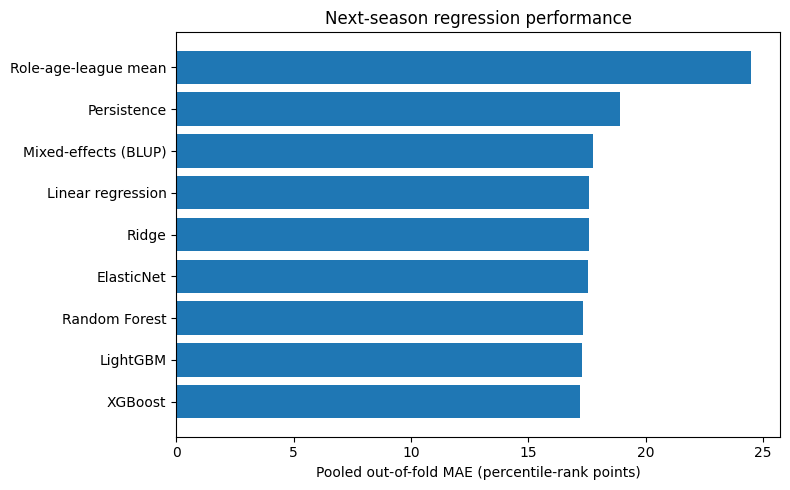

Saved canonical model outputs.


In [8]:
oof.to_csv(P['predictions'] / '04_out_of_fold_predictions.csv',index=False)
pooled.to_csv(P['tables'] / '04_regression_metrics_pooled.csv',index=False)
pd.DataFrame([fixed_diag]).to_csv(P['tables'] / '04_mixed_fixed_only_diagnostic.csv',index=False)
by_fold.to_csv(P['tables'] / '04_regression_metrics_by_fold.csv',index=False)
by_role.to_csv(P['tables'] / '04_regression_metrics_by_role.csv',index=False)
tuning_df.to_csv(P['tables'] / '04_hyperparameter_tuning.csv',index=False)
mixed_diag_df.to_csv(P['tables'] / '04_mixed_effects_diagnostics.csv',index=False)
blup_summary.to_csv(P['tables'] / '04_mixed_effects_blup_summary.csv',index=False)

for model_name,frames in feature_importance.items():
    imp=pd.concat(frames,axis=1).fillna(0.0)
    imp['mean_importance']=imp.mean(axis=1)
    imp.sort_values('mean_importance',ascending=False).to_csv(P['tables'] / f"04_feature_importance_{model_name.lower().replace(' ','_')}.csv")

fig,ax=plt.subplots(figsize=(8,5))
plot_df=pooled.sort_values('MAE',ascending=True)
ax.barh(plot_df['model'],plot_df['MAE'])
ax.set_xlabel('Pooled out-of-fold MAE (percentile-rank points)')
ax.set_title('Next-season regression performance')
fig.tight_layout()
fig.savefig(P['figures'] / '04_pooled_regression_mae.png',dpi=160,bbox_inches='tight')
plt.show()

print('Saved canonical model outputs.')


In [ ]:
# Report figure regenerated from the saved role-level metrics.
xgb_role = by_role[by_role['model']=='XGBoost'].copy().sort_values('role')
fig,ax=plt.subplots(figsize=(6.5,4.2))
ax.bar(xgb_role['role'],xgb_role['MAE'])
ax.set_ylabel('MAE (percentile-rank points)')
ax.set_xlabel('Broad role')
ax.set_title('XGBoost MAE by broad playing role')
fig.tight_layout(); fig.savefig(P['figures']/'04_xgboost_mae_by_role.png',dpi=160,bbox_inches='tight'); plt.show()

## Stage conclusion

Across the four chronological test folds, the primary comparison uses one held-out next-season prediction per scored player-season transition. The mixed-effects implementation applies player-specific random intercepts only to returning players observed in the training history; previously unseen players remain in the evaluation through the fixed-effects component. Hyperparameter selection is nested within each chronological training window.